<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 8</h3>
    <h3>Ejercicio 3</h3>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistente: Sebastián Calcagno<p>
</div>

# ESPACIO PARA COMPARTIR CODIGO E IDEAS

TSMixer

Ahora vamos a trabajar con tres ejemplos en torno al modelo TSMixer que es una red neuronal para predecir series temporales.

-	En el EJEMPLO 1 vamos a trabajar con Pytorch desde cero.
Trabajamos con un dataset q registra sensores de un transformador eléctrico (temperatura del aceite, cargas alta/media/baja). Pasos en general =
1.	Descarga y preprocesa los datos y normalizamos.
2.	Conviertir la serie en un problema supervisado usando ventanas deslizantes.
3.	Definir e implementar la arquitectura manualmente en PyTorch: alterna bloques de token mixing (aprende patrones dentro de cada variable) y channel mixing (aprende relaciones entre variables), con conexiones residuales.
4.	Entrenar el modelo durante 50 épocas usando MSE como función de pérdida y Adam como optimizador.
5.	Graficar las predicciones vs. los valores reales para las 4 variables.


En el EJEMPLO 2 usamos la librería Darts para comparar dos modelos:

 - TSMixerModel (el mismo concepto pero ya empaquetado)
 -	TiDEModel (Time-series Dense Encoder, de Google Research 2023)
Ambos se entrenan con early stopping, se evalúan con Mean Quantile Loss en distintos cuantiles (0.05 a 0.95, predicciones probabilísticas) y se grafican comparando pronóstico vs. realidad sobre ETTh1 y ETTh2.


 - [Paper original de tidemodel](https://arxiv.org/abs/2304.08424)
 - [Explicacion y ejemplos del modelo Tidemodel](https://www.datasciencewithmarco.com/blog/time-series-forecasting-with-tide)


En el EJEMPLO 3 usamos la librería Neuralforecast ( de nixtla) con el dataset pedagojico de ventas de champú (serie mensual). Configurmos TSMixer con 24 meses de historia para predecir 6 meses hacia adelante, entrena el modelo y grafica el histórico junto con la predicción futura.


 -  [Documentacion de Nixtla](https://nixtla.github.io/neuralforecast/)

## EJEMPLO 1

Aca hacemos trabajamso con una serie temporal real, la convertimos en un problema supervisado y entrenamos una red neuronal (TSMixer) para predecir el futuro a partir del pasado.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn  # redes neuronales de PyTorch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
url = 'https://raw.githubusercontent.com/sebcalcagno/AnalisisSeriesTemporales/refs/heads/main/ETTh1_original.csv'
df = pd.read_csv(url)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

ETTh1 es dataset de sensores que registra el comportamiento de un transformador electrico:

OT = Temperatura del aceite del transformador  <BR>
HUFL = High-Use Feature Load <BR>
MUFL = Medium-Use Feature Load <BR>
LUFL = Low-Use Feature Load


In [ ]:
df.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [ ]:
cols = ['OT', 'HUFL', 'MUFL', 'LUFL']  # target y otras features
data = df[cols].dropna()

In [ ]:
data.head()

,OT,HUFL,MUFL,LUFL
date,,,,
2016-07-01 00:00:00,30.531000,5.827,1.599,4.203
2016-07-01 01:00:00,27.787001,5.693,1.492,4.142
2016-07-01 02:00:00,27.787001,5.157,1.279,3.777
2016-07-01 03:00:00,25.044001,5.090,1.279,3.807
2016-07-01 04:00:00,21.948000,5.358,1.492,3.868


A continuacion esto aporta lo siguiente =
- Mejora la estabilidad numerica.
- Acelera el entrenamiento.
- Evita que variables con escalas distintas dominen a otras

Normalizamos los datos para usarlos en el ejercicio

In [ ]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled = torch.tensor(data_scaled, dtype=torch.float32)

La proxima funcion me permite convertir un solo archivo de datos en miles de ejemplos de entrenamiento para que TSMixer aprenda a predecir series temporales. Se generan miles de pares de (entrada, salida) que nuestro modelo puede usar para aprender a predecir el futuro.Es decir, transformamos una serie temporal en un dataset supervisado (cada bloque de 96 pasos sirve para predecir los 24 siguientes). Es decir, sliding windows (ventanas deslizantes)

In [ ]:
def create_windows(data, input_len=96, pred_len=24):
    X, y = [], []
    for i in range(len(data) - input_len - pred_len):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+pred_len])
    return torch.stack(X), torch.stack(y)

X, y = create_windows(data_scaled, input_len=96, pred_len=24)
print("Shape X:", X.shape)

Shape X: torch.Size([17300, 96, 4])


[Texto anexo de referencia](https://towardsdatascience.com/applications-of-rolling-windows-for-time-series-with-python-1a4bbe44901d/)

In [ ]:
X

tensor([[[ 2.0085, -0.2190, -0.3957,  0.9764],
         [ 1.6882, -0.2380, -0.4114,  0.9240],
         [ 1.6882, -0.3138, -0.4426,  0.6105],
         ...,
         [ 2.0085,  0.4254,  0.3799,  0.3752],
         [ 1.6717,  0.3212,  0.3383,  0.1657],
         [ 1.4173,  0.7571,  0.7391,  0.0875]],

        [[ 1.6882, -0.2380, -0.4114,  0.9240],
         [ 1.6882, -0.3138, -0.4426,  0.6105],
         [ 1.3680, -0.3233, -0.4426,  0.6363],
         ...,
         [ 1.6717,  0.3212,  0.3383,  0.1657],
         [ 1.4173,  0.7571,  0.7391,  0.0875],
         [ 1.4747,  0.6528,  0.6558,  0.1133]],

        [[ 1.6882, -0.3138, -0.4426,  0.6105],
         [ 1.3680, -0.3233, -0.4426,  0.6363],
         [ 1.0066, -0.2854, -0.4114,  0.6887],
         ...,
         [ 1.4173,  0.7571,  0.7391,  0.0875],
         [ 1.4747,  0.6528,  0.6558,  0.1133],
         [ 1.4747,  0.7287,  0.6818,  0.0609]],

        ...,

        [[-0.4057, -0.2664, -0.3072,  0.0609],
         [-0.4303, -0.1906, -0.1927,  0.0085]

Aca se define el modelo TSMixer.

Parametros:

input_len: pasos de entrada.
pred_len: pasos a predecir.
n_features: numero de variables en el dataset.
hidden_dim: dimension intermedia en el channel mixer.
n_blocks: cantidad de bloques de mixers (la profundidad de la red).

In [ ]:
class TSMixer(nn.Module):
    def __init__(self, input_len, pred_len, n_features, hidden_dim=64, n_blocks=2):
        super().__init__()   # aca guardamos los parametros principales del modelo q desp usaremos para definir las capas
        self.input_len = input_len
        self.pred_len = pred_len
        self.n_features = n_features

        self.token_mixers = nn.ModuleList()
        self.channel_mixers = nn.ModuleList()

        for _ in range(n_blocks):

            #Aca se separa el el aprendizaje en dos dimensiones:
            #1º aprende patrones temporales individuales de cada variable (token mixing).
            #2º aprende patrones temporales globales (channel mixing).
            #Finalmente proyecta esos patrones aprendidos al futuro.
            self.token_mixers.append(nn.Sequential(
                nn.LayerNorm(input_len),
                nn.Linear(input_len, input_len),
                nn.GELU(),
                nn.Linear(input_len, input_len),
            ))

            self.channel_mixers.append(nn.Sequential(
                nn.LayerNorm(n_features),
                nn.Linear(n_features, hidden_dim),
                nn.GELU(),
                nn.Linear(hidden_dim, n_features),
            ))
         # Proyeccion de salida ( convierte de 96 pasos de entrada en 24 pasos de salida )
        self.output_proj = nn.Linear(input_len, pred_len)

#Este bloque toma los datos de entrada, los procesa con bloques MLP (Multilayer Perceptron )

#para mezclar información en el tiempo y entre variables y luego proyecta la salida para predecir los prox pasos de la serie temporal.

    def forward(self, x):

        x = x.permute(0, 2, 1)

        for token_mixer, channel_mixer in zip(self.token_mixers, self.channel_mixers):

            res = x
            x = token_mixer(x)
            x = x + res


            x = x.permute(0, 2, 1)
            res = x
            x = channel_mixer(x)
            x = x + res


            x = x.permute(0, 2, 1)


        x = self.output_proj(x)
        return x.permute(0, 2, 1)


Aca se entrena entrena el modelo TSMixer durante 50 epocs con PyTorch.
Ajusta los pesos del modelo TSMixer para que aprenda a predecir el futuro a partir de ejemplos pasados y va supervisando su desempeño.

Aca entrenamos el modelo es donde donde la red empieza a aprender.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TSMixer(input_len=96, pred_len=24, n_features=len(cols)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # Optimizador Adam con tasa de aprendizaje 0.001
loss_fn = nn.MSELoss()  # Loss function MSE (Mean Squared Error) estandar en regresion de series temporales.

X_train, y_train = X[:-200], y[:-200]
X_val, y_val = X[-200:], y[-200:]

for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train.to(device))
    loss = loss_fn(y_pred, y_train.to(device))
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val.to(device))
            val_loss = loss_fn(val_pred, y_val.to(device))
        print(f"Epoch {epoch}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

Epoch 0, Train Loss: 1.4297, Val Loss: 1.4865
Epoch 10, Train Loss: 0.6086, Val Loss: 0.5957
Epoch 20, Train Loss: 0.4150, Val Loss: 0.3742
Epoch 30, Train Loss: 0.3602, Val Loss: 0.3428
Epoch 40, Train Loss: 0.3326, Val Loss: 0.3255


A medida que avanzan las epoc el modelo esta aprendiendo y mejorando su desempeño ya que tanto el Train Loss como el Val Loss disminuyen.

Si Val Loss comienza a aumentar mientras que Train Loss sigue bajando, podría ser una señal de overfitting (sobreajuste).

Ahora usa el modelo TSMixer para predecir los prox pasos de una serie de tiempo y guarda tanto la prediccion como el valor real para poder compararlos.

Es decir, aca se genera las predicciones del modelo sobre la ultima ventana de validacion y prepara tanto las predicciones (pred) como los valores reales (actual) en formato numpy para analizarlos o graficarlos

In [ ]:
# usamos los ultimos 96 datos para predecir el futuro y lo comparamos con la realidad.
model.eval()
with torch.no_grad():
    pred = model(X_val[-1:].to(device)).cpu().squeeze(0).numpy()
    actual = y_val[-1].numpy()

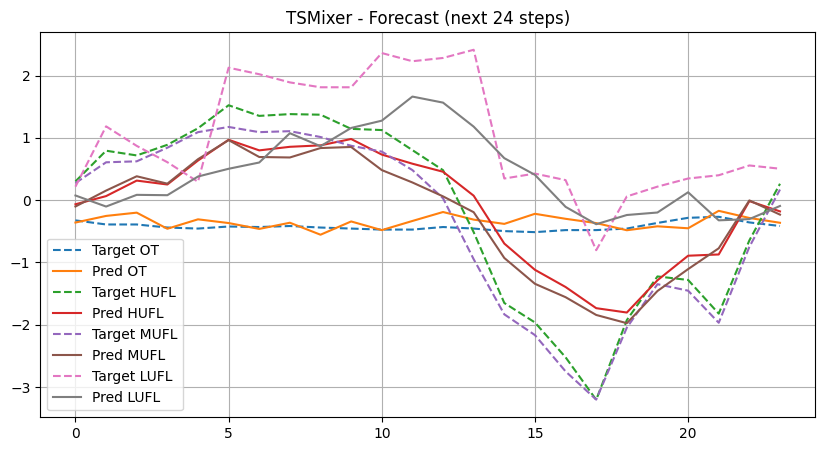

In [ ]:
plt.figure(figsize=(10, 5))
for i in range(len(cols)):
    plt.plot(actual[:, i], label=f'Target {cols[i]}', linestyle='--')
    plt.plot(pred[:, i], label=f'Pred {cols[i]}')
plt.title("TSMixer - Forecast (next 24 steps)")
plt.legend()
plt.grid()
plt.show()


In [ ]:
import pandas as pd
import numpy as np


n_features = pred.shape[1]
columns = [f'Var_{i+1}' for i in range(n_features)]


df_resultado = pd.DataFrame()

for i, col in enumerate(columns):
    df_resultado[f'{col}_Real'] = actual[:, i]
    df_resultado[f'{col}_Pred'] = pred[:, i]


print(df_resultado.head(50))

    Var_1_Real  Var_1_Pred  Var_2_Real  Var_2_Pred  Var_3_Real  Var_3_Pred  \
0    -0.323657   -0.358444    0.302207   -0.065321    0.275790   -0.100795   
1    -0.389376   -0.252124    0.795023    0.066128    0.608890    0.154637   
2    -0.389376   -0.199557    0.719184    0.315118    0.624564    0.384545   
3    -0.438637   -0.458177    0.889823    0.252322    0.843115    0.265891   
4    -0.455096   -0.306778    1.155120    0.636878    1.093013    0.658640   
5    -0.422178   -0.366641    1.524839    0.970376    1.176361    0.965009   
6    -0.430349   -0.460778    1.354199    0.800295    1.093013    0.693986   
7    -0.414007   -0.361375    1.382639    0.857676    1.108686    0.686342   
8    -0.438637   -0.553886    1.373159    0.880908    1.014938    0.837734   
9    -0.455096   -0.340857    1.145640    0.982830    0.874462    0.854944   
10   -0.471438   -0.480190    1.126680    0.732937    0.780713    0.484072   
11   -0.471438   -0.333204    0.804503    0.586290    0.483941  

El modelo no predice una sola variable sino las 4 variables a la vez=

OT	Temperatura del transformador <br>
HUFL	High-Use Feature Load <br>
MUFL	Medium-Use Feature Load <br>
LUFL	Low-Use Feature Load <br>

## EJEMPLO 2 - LIBRERIA DARTS

https://unit8co.github.io/darts/

TiDE (Time-series Dense Encoder) es un modelo propuesto por Google Research en 2023. TiDE es un modelo rapido y flexible para forecasting multivariado ideal cuando tenes muchas covariables y queres buena performance sin complicarte con arquitecturas pesadas.

[Link documentacion](https://research.google/pubs/long-horizon-forecasting-with-tide-time-series-dense-encoder/)

In [ ]:
! pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 760.5/760.5 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.7/364.7 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmli

In [ ]:
! pip install pytorch_lightning  # aca se ayuda a entrenar modelos + rapidos con menos codigo + limpieza y mejores practicas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.5 MB/s eta 0:00:00


In [ ]:
! pip install utils

  Preparing metadata (setup.py) ... done
  Created wheel for utils: filename=utils-1.0.2-py2.py3-none-any.whl size=13906 sha256=791a77ed3dba43388133fa1ca2bc544bc69558e85409027057200503babe6fa2
  Stored in directory: /root/.cache/pip/wheels/b6/a1/81/1036477786ae0e17b522f6f5a838f9bc4288d1016fc5d0e1ec
Successfully built utils


In [ ]:
# %load_ext autoreload
# %autoreload 2
# %matplotlib inline

In [ ]:
import warnings

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

from darts import concatenate
from darts.dataprocessing.transformers.scaler import Scaler
from darts.datasets import ETTh1Dataset, ETTh2Dataset
from darts.metrics import mql
from darts.models import TiDEModel, TSMixerModel   #TSMixerModel: version oficial del time Series Mixer.
from darts.utils.callbacks import TFMProgressBar
from darts.utils.likelihood_models.torch import QuantileRegression

In [ ]:
# transformer_id es una etiqueta q indica de q dataset viene cada serie.
# Asi entrenamos modelos en datasets multiserie donde cada serie representa una entidad distinta
# Carga dos datasets de series temporales (ETTh1 y ETTh2) como objetos TimeSeries de Darts.

series = []
for idx, ds in enumerate([ETTh1Dataset, ETTh2Dataset]):
    trafo = ds().load().astype(np.float32)
    trafo = trafo.with_static_covariates(pd.DataFrame({"transformer_id": [idx]}))
    series.append(trafo)
series[0].to_dataframe()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000
...,...,...,...,...,...,...,...
2018-06-26 15:00:00,-1.674,3.550,-5.615,2.132,3.472,1.523,10.904000
2018-06-26 16:00:00,-5.492,4.287,-9.132,2.274,3.533,1.675,11.044000
2018-06-26 17:00:00,2.813,3.818,-0.817,2.097,3.716,1.523,10.271000


La ventaja de Darts es que mantiene el orden temporal no mezcla pasado con futuro y devuelve objetos TimeSeries listos para entrenar modelos.

Aca separa : 60 % train 20 % val y 20 % test

In [ ]:
train, val, test = [], [], []
for trafo in series:
    train_, temp = trafo.split_after(0.6)
    val_, test_ = temp.split_after(0.5)
    train.append(train_)
    val.append(val_)
    test.append(test_)

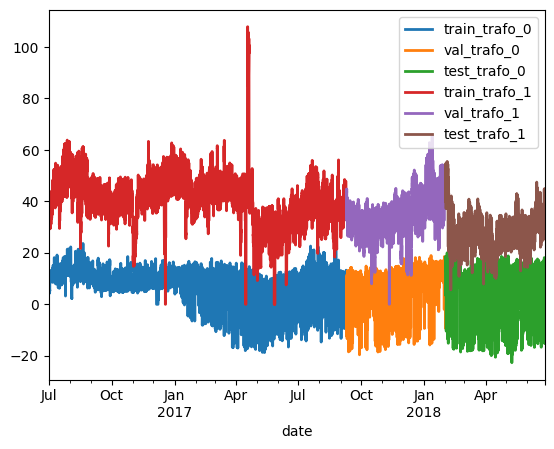

In [ ]:
show_col = "HUFL"
for idx, (train_, val_, test_) in enumerate(zip(train, val, test)):
    train_[show_col].plot(label=f"train_trafo_{idx}")
    val_[show_col].plot(label=f"val_trafo_{idx}")
    test_[show_col].plot(label=f"test_trafo_{idx}")

In [ ]:
scaler = Scaler()
train = scaler.fit_transform(train)
val = scaler.transform(val)
test = scaler.transform(test)

In [ ]:
def create_params(
    input_chunk_length: int,
    output_chunk_length: int,
    full_training=True,
):
    # Corta el entrenamiento si val_loss no mejora en 10 eopcs por al menos 1e-5.

    early_stopper = EarlyStopping(
        monitor="val_loss",
        patience=10,
        min_delta=1e-5,
        mode="min",
    )

    # define cuantas epocs y tamaño de batch usar
    if full_training:
        limit_train_batches = None
        limit_val_batches = None
        max_epochs = 200
        batch_size = 256
    else:
        limit_train_batches = 20
        limit_val_batches = 10
        max_epochs = 40
        batch_size = 64   # 64  para pruebas rapidas  ; 256 para full training

    # visualiza el progreso de entrenamiento
    progress_bar = TFMProgressBar(
        enable_sanity_check_bar=False, enable_validation_bar=False
    )
    pl_trainer_kwargs = {              # define la configuracion para el entrenador de PyTorch q Darts usa internamente
        "gradient_clip_val": 1,
        "max_epochs": max_epochs,
        "limit_train_batches": limit_train_batches,
        "limit_val_batches": limit_val_batches,
        "accelerator": "auto",
        "callbacks": [early_stopper, progress_bar],
    }

    # optimizer usa Adam por default
    #
    optimizer_kwargs = {
        "lr": 1e-4,   # el modelo va a hacer ajustes pequeños y progresivos, valores + altos ajustan + rpido pero pueden volverse inestables.
    }

    # aca seconfigura que el learning rate se reduzca un poco en cada epocs para que el entrenamiento empiece mas fuerte y termine ajustando fino
    lr_scheduler_cls = torch.optim.lr_scheduler.ExponentialLR
    lr_scheduler_kwargs = {"gamma": 0.999}

    # aca tenemos un diccionario completo de configuracion para crear el modelo con todos los hiperparametros necesarios
    likelihood = QuantileRegression()
    loss_fn = None

    return {
        "input_chunk_length": input_chunk_length,
        "output_chunk_length": output_chunk_length,
        "use_reversible_instance_norm": True,
        "optimizer_kwargs": optimizer_kwargs,
        "pl_trainer_kwargs": pl_trainer_kwargs,
        "lr_scheduler_cls": lr_scheduler_cls,
        "lr_scheduler_kwargs": lr_scheduler_kwargs,
        "likelihood": likelihood,
        "loss_fn": loss_fn,
        "save_checkpoints": True,
        "force_reset": True,
        "batch_size": batch_size,
        "random_state": 42,
        "add_encoders": {
            "cyclic": {
                "future": ["hour", "dayofweek", "month"]
            }
        },
    }

Aca se esta configurando un modelo que:

Mire 1 semana para predecir 1 día, use covariables estaticas ( son las  etiquetas que ayudan al modelo a entender de q entidad proviene cada serie) y entrena de forma rapida para testear

In [ ]:
input_chunk_length = 7 * 24
output_chunk_length = 24
use_static_covariates = True
full_training = False

Aca se implementa Darts de un modelo TSMixer y TiDEModel( q es otro tipo de modelo deep learning para series temporales de Darts, especializado en capturar dependencias temporales y covariables)

In [ ]:
model_tsm = TSMixerModel(
    **create_params(
        input_chunk_length,
        output_chunk_length,
        full_training=full_training,
    ),
    use_static_covariates=use_static_covariates,
    model_name="tsm",
)
model_tide = TiDEModel(
    **create_params(
        input_chunk_length,
        output_chunk_length,
        full_training=full_training,
    ),
    use_static_covariates=use_static_covariates,
    model_name="tide",
)
models = {
    "TSM": model_tsm,
    "TiDE": model_tide,
}

Aca hace todo automaticamente:

-Entrena cada modelo con train + val.

-Monitorea val_loss y aplica early stopping.

-Guarda checkpoints y luego carga el mejor modelo.

In [ ]:
#Aca se entrena los modelos y se asegura que luego se use el mejor modelo guardado automaticamente
for model_name, model in models.items():
    model.fit(
        series=train,
        val_series=val,
    )

    models[model_name] = model.load_from_checkpoint(
        model_name=model.model_name, best=True, weights_only=False
    )

┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ train_metrics         │ MetricCollection │      0 │ train │     0 │
│ 1 │ val_metrics           │ MetricCollection │      0 │ train │     0 │
│ 2 │ rin                   │ RINorm           │     14 │ train │     0 │
│ 3 │ fc_hist               │ Linear           │  4.1 K │ train │     0 │
│ 4 │ feature_mixing_hist   │ _FeatureMixing   │  9.0 K │ train │     0 │
│ 5 │ feature_mixing_future │ _FeatureMixing   │  8.1 K │ train │     0 │
│ 6 │ conditional_mixer     │ ModuleList       │ 87.2 K │ train │     0 │
│ 7 │ fc_out                │ Linear           │  7.7 K │ train │     0 │
└───┴───────────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 116 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 116 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 67                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training: 0it [00:00, ?it/s]

┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                  ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ train_metrics         │ MetricCollection │      0 │ train │     0 │
│ 1 │ val_metrics           │ MetricCollection │      0 │ train │     0 │
│ 2 │ rin                   │ RINorm           │     14 │ train │     0 │
│ 3 │ future_cov_projection │ _ResidualBlock   │  1.4 K │ train │     0 │
│ 4 │ encoders              │ Sequential       │  514 K │ train │     0 │
│ 5 │ decoders              │ Sequential       │  1.7 M │ train │     0 │
│ 6 │ temporal_decoder      │ _ResidualBlock   │ 45.8 K │ train │     0 │
│ 7 │ lookback_skip         │ Linear           │ 69.0 K │ train │     0 │
└───┴───────────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.3 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 34                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Training: 0it [00:00, ?it/s]

 q hacemos aca=

Genera predicciones probabilisticas históricas (historical_forecasts)

Evalua su precisión con Mean Quantile Loss (backtest)

Y visualiza los pronosticos vs. la verdad real (generate_plots)

In [ ]:

num_samples = 500
forecast_horizon = output_chunk_length


evaluate_quantiles = [0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95]


def historical_forecasts(model):
    """
    """
    hfc = model.historical_forecasts(
        series=test,
        forecast_horizon=forecast_horizon,
        stride=forecast_horizon,
        last_points_only=False,
        retrain=False,
        num_samples=num_samples,
        verbose=True,
    )
    return scaler.inverse_transform(hfc)


def backtest(model, hfc, name):
    """Evalua pronósticos historicos probabilísticos utilizando la Perdida Cuantil Media (PCM) sobre un conjunto de cuantiles"""

    metric_kwargs = [{"q": q} for q in evaluate_quantiles]
    metrics = [mql for _ in range(len(evaluate_quantiles))]
    bt = model.backtest(
        series=series,
        historical_forecasts=hfc,
        last_points_only=False,
        metric=metrics,
        metric_kwargs=metric_kwargs,
        verbose=True,
    )
    bt = pd.DataFrame(
        bt,
        columns=[f"q_{q}" for q in evaluate_quantiles],
        index=[f"{trafo}_{name}" for trafo in ["ETTh1", "ETTh2"]],
    )
    return bt


def generate_plots(n_days, hfcs):



    hfcs_plot = {}
    for model_name, hfc_model in hfcs.items():
        hfcs_plot[model_name] = [
            concatenate(hfc_series[-n_days:], axis=0) for hfc_series in hfc_model
        ]


    hfc_ = hfcs_plot[model_name][0]
    start, end = hfc_.start_time(), hfc_.end_time()


    for col in series[0].columns:
        fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

        for trafo_idx, trafo in enumerate(series):
            trafo[col][start:end].plot(label="ground truth", ax=axes[trafo_idx])

            for model_name, hfc in hfcs_plot.items():
                hfc[trafo_idx][col].plot(
                    label=model_name + "_q0.05-q0.95", ax=axes[trafo_idx]
                )
            axes[trafo_idx].set_title(f"ETTh{trafo_idx + 1}: {col}")
        plt.show()

Aca se genera y evalua las predicciones probabilísticas de cada modelo (TSM y TiDE) sobre el conjunto de prueba, y guarda:
hfcs: las predicciones
bts: las metricas de error



In [ ]:
bts = {}
hfcs = {}
for model_name, model in models.items():
    print(f"Model: {model_name}")
    print("Generating historical forecasts..")
    hfcs[model_name] = historical_forecasts(models[model_name])

    print("Evaluating historical forecasts..")
    bts[model_name] = backtest(models[model_name], hfcs[model_name], model_name)

Model: TSM
Generating historical forecasts..


Predicting: 0it [00:00, ?it/s]

Generating TimeSeries: 100%|██████████| 276/276 [00:00<00:00, 3044.04it/s]


Evaluating historical forecasts..
Model: TiDE
Generating historical forecasts..


Predicting: 0it [00:00, ?it/s]

Generating TimeSeries: 100%|██████████| 276/276 [00:00<00:00, 3109.43it/s]


Evaluating historical forecasts..


Aca se junta las metricas de error de los modelos entrenados y podemosver de un vistazo cual modelo predice mejor en cada serie y en cada cuantil.

In [ ]:
bt_df = pd.concat(bts.values(), axis=0).sort_index()
bt_df

# Cada celda representa el error de prediccion promedio en un determinado cuantil, con menor valor = mejor.
# Porq saber los errores por cuantil te permite medir q tan confiable es el modelo en sus predicciones extremas y no solo en la media.

,q_0.05,q_0.1,q_0.2,q_0.5,q_0.8,q_0.9,q_0.95
ETTh1_TSM,0.481981,0.735463,1.095138,1.512900,1.047354,0.667080,0.408303
ETTh1_TiDE,0.574299,0.887158,1.298496,1.665831,1.152619,0.728946,0.447333
ETTh2_TSM,0.618436,0.975163,1.436808,1.852263,1.270717,0.811181,0.489227
ETTh2_TiDE,0.624578,0.979514,1.448814,1.894301,1.323398,0.863714,0.530451


In [ ]:
bt_df.mean(axis=1)

# aca vemos el error promedio en todos los cuantiles ( mejores resultados : ETTh1_TSM)

,0
ETTh1_TSM,0.849746
ETTh1_TiDE,0.964955
ETTh2_TSM,1.064828
ETTh2_TiDE,1.094967


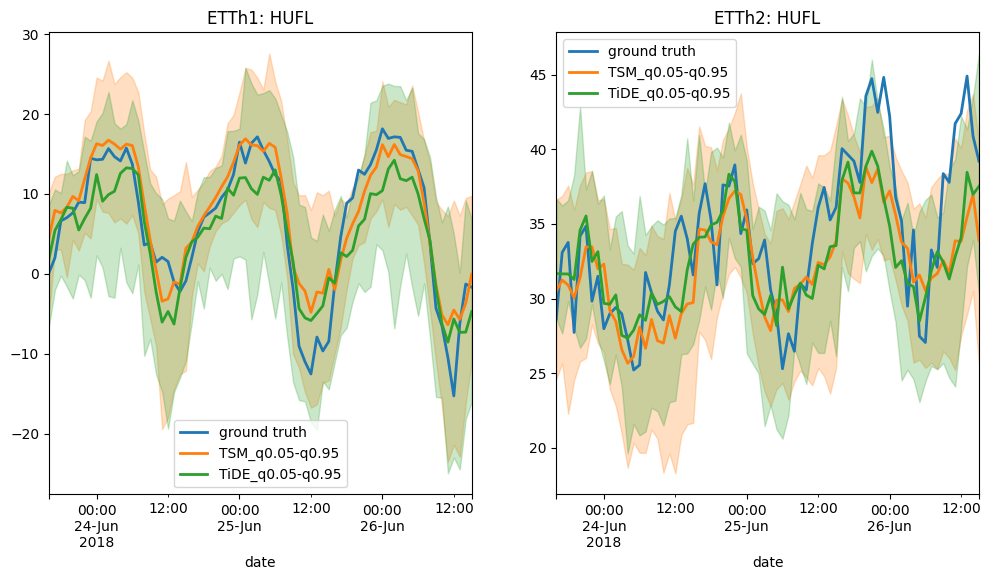

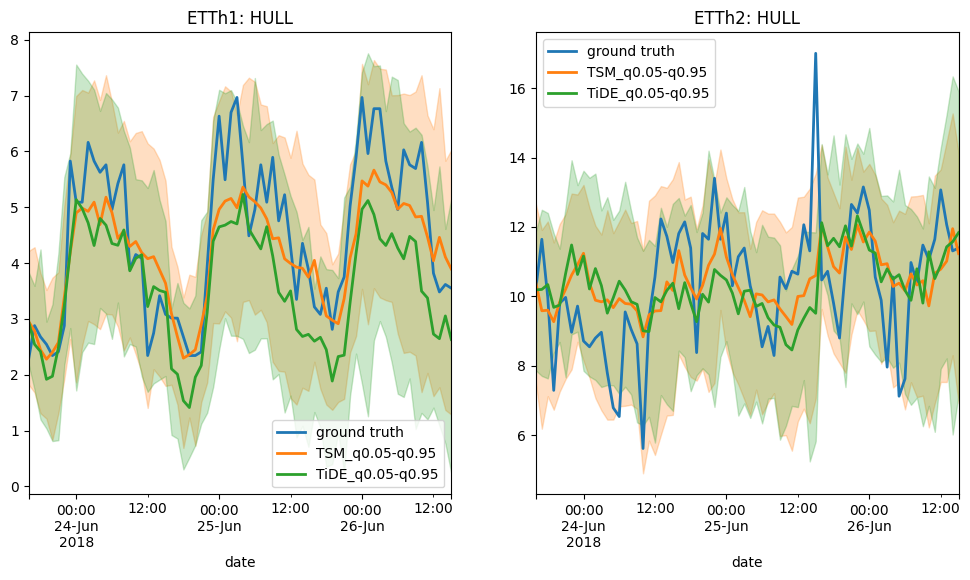

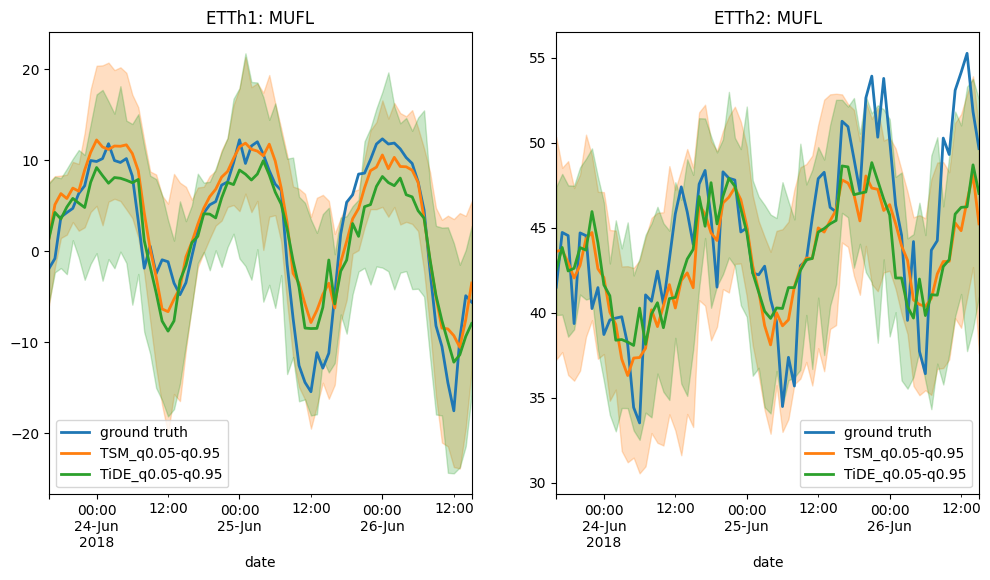

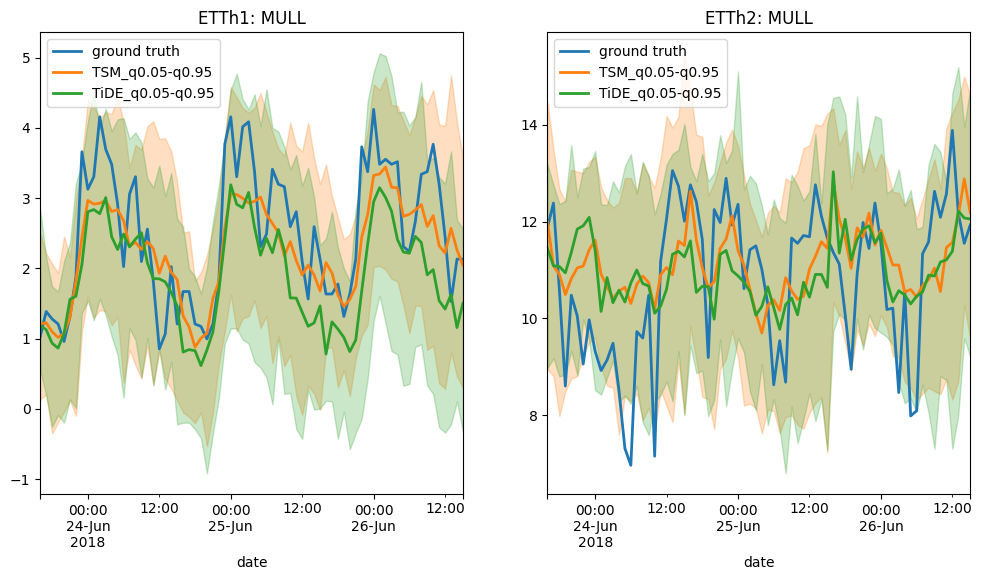

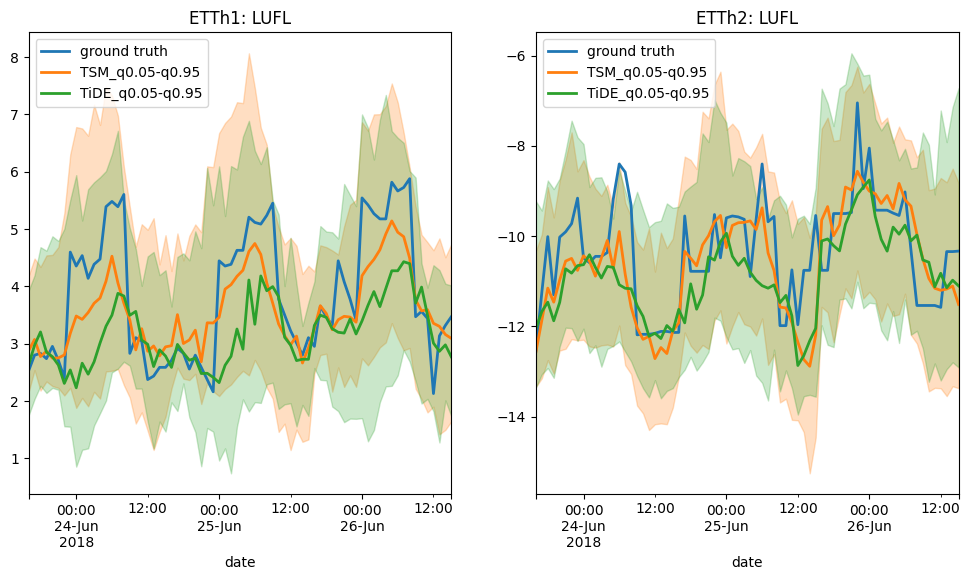

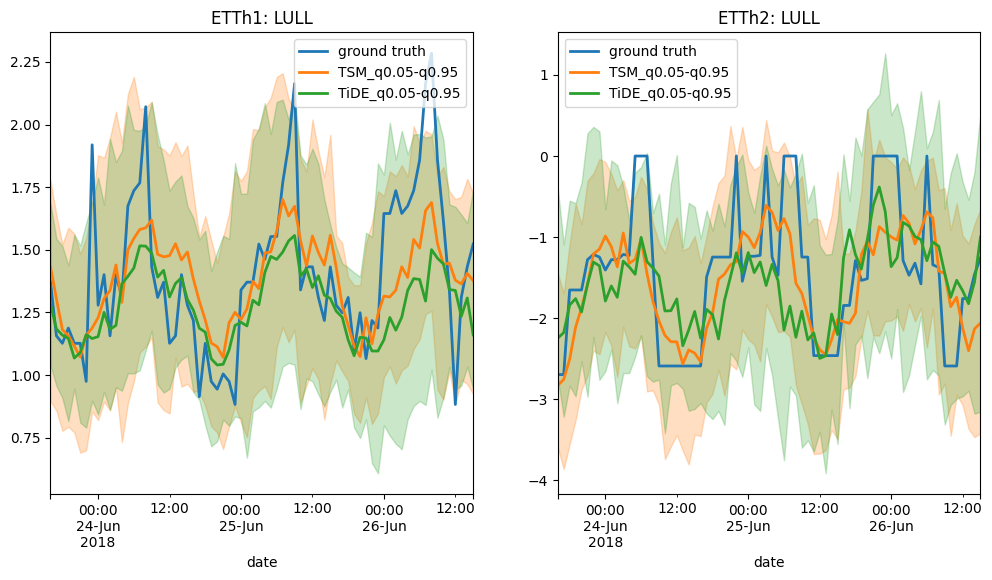

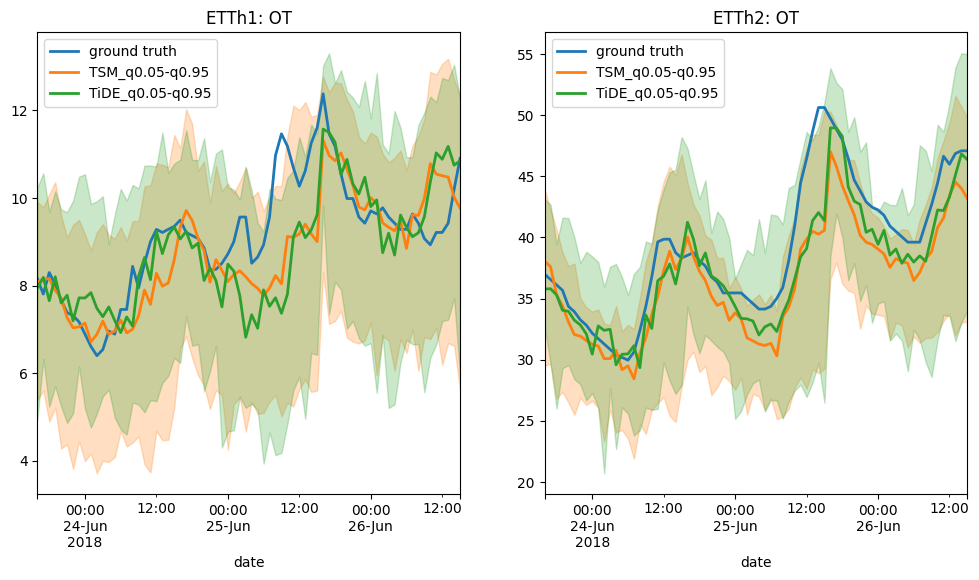

In [ ]:
generate_plots(n_days=3, hfcs=hfcs)

## Ejemplo 3

Ejemplo funcional en Colab con TSMixer y dataset Shampoo Sales

https://github.com/ditschuk/pytorch-tsmixer

https://nixtla.github.io/neuralforecast1/

Porque NeuralForecast?:  
Ya maneja toda la lógica para armar ventanas de entrenamiento (input_size) y pasos futuros (h).

Soporta entrenamiento por lotes y múltiples series (unique_id).

Compatible con PyTorch Lightning.

Interfaz simple y amigable.

In [ ]:
# !pip install neuralforecast torch pandas matplotlib --quiet


!pip uninstall -y torchvision torchaudio
!pip install torch==2.6.0 --force-reinstall
!pip install neuralforecast --upgrade

Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 793.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: tornado
    Found existing installation: tornado 6.5.1
    Uninstalling tornado-6.5.1:
      Successfully uninstalled tornado-6.5.1
^C


In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from neuralforecast import NeuralForecast
from neuralforecast.models import TSMixer
from neuralforecast.losses.pytorch import MAE

In [ ]:
# Cargar dataset shampoo (mensual)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv"
df = pd.read_csv(url, header=0)
df.columns = ['ds', 'y']
df['ds'] = pd.date_range(start='1901-01-01', periods=len(df), freq='MS')
df['unique_id'] = 'shampoo_series'

In [ ]:
# 4️⃣ Configurar modelo TSMixer con parámetros compatibles
horizon = 6          # Número de pasos a predecir
input_size = 24      # Ventana de historia meses
model = TSMixer(
    h=horizon,
    input_size=input_size,
    n_series=1,  #  solo una shampoo_series.
    # No usamos exógenas en este caso (TSMixer sin covariables),
    n_block=2,  # n de bloques TSMixer
    ff_dim=64,   # dimensi0n de la red feed-forward dentro de cada bloque. + grande = + capacidad, pero mas riesgo de sobreajuste.
    dropout=0.1,
    revin=True,
    loss=MAE(),
    learning_rate=1e-3,
    max_steps=300,
    batch_size=16,
    windows_batch_size=32,
)

INFO:lightning_fabric.utilities.seed:Seed set to 1


In [ ]:
#  Crear pipeline de forecast
# Voy a entrenar un NeuralForecast que use un modelo TSMixer con datos de frecuencia mensual
nf = NeuralForecast(models=[model], freq='MS')

In [ ]:
# Entrenar modelo
nf.fit(df=df)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type              | Params | Mode 
------------------------------------------------------------
0 | loss          | MAE               | 0      | train
1 | padder_train  | ConstantPad1d     | 0      | train
2 | scaler        | TemporalNorm      | 0      | train
3 | norm          | RevINMultivariate | 2      | train
4 | mixing_layers | Sequential        | 1.8 K  | train
5 | out           | Linear            | 150    | train
------------------------------------------------------------
1.9 K     Trainable params
0         Non-trainable params
1.9 K     Total params
0.008     Total estimated model para

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


In [ ]:
# Hacer predicción
y_hat = nf.predict()  # Devuelve DataFrame con columna 'TSMixer' :contentReference[oaicite:3]{index=3}

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

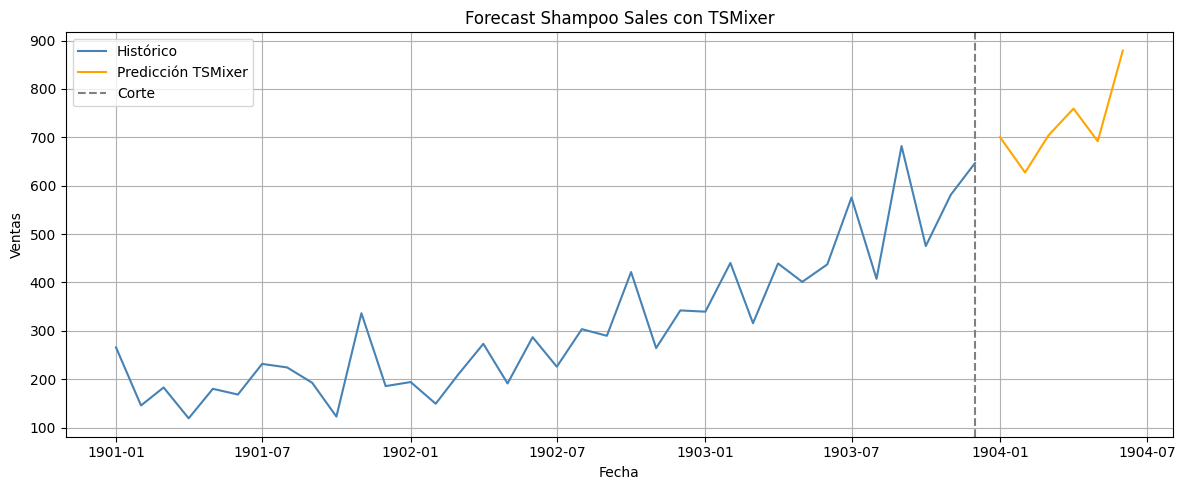

In [ ]:
#  Graficar histórico + predicción
hist = df.copy()
fc = y_hat.copy()
fc_dates = pd.date_range(start=hist['ds'].iloc[-1] + pd.DateOffset(months=1),
                         periods=horizon, freq='MS')

plt.figure(figsize=(12, 5))
plt.plot(hist['ds'], hist['y'], label='Histórico', color='steelblue')
plt.plot(fc_dates, fc['TSMixer'].values, label='Predicción TSMixer', color='orange')
plt.axvline(hist['ds'].iloc[-1], linestyle='--', color='gray', label='Corte')
plt.legend()
plt.title("Forecast Shampoo Sales con TSMixer")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.tight_layout()
plt.show()

# ESPACIO PARA TRABAJAR

Aqui cada uno aplicara lo visto sobre su propio dataset tomando decisiones de diseño y justificando sus elecciones a lo largo del proceso. La idea es implementar y comparar modelos ya sea distintos o el mismo con diferentes parámetros o decisiones tomadas en base a sus datasets.

Plan de trabajo sugerido (RECUERDEN QUE ESTO ES UNA GUIA SUGERIDA, PUEDEN TRABAJAR COMO LES RESUELTE MAS COMODO)=

- Parte 1 - Carga y exploración del dataset = Cargar el dataset y realizar una exploracion inicial.

.	Visualizar la serie objetivo e identificar patrones visibles: tendencia, estacionalidad, outliers.<br>
.	Justificar brevemente la elección del dataset y su relevancia.

- Parte 2 - preprocesamiento y construccion del dataset supervisado. Tratar valores faltantes si los hubiera (imputación, eliminación u otra estrategia justificada).

.	Normalizar o estandarizar las variables segun corresponda.<br>
.	Definir y justificar los hiperparametros de ventana:
•	input_len / input_chunk_length <br>
•	pred_len / output_chunk_length<br>
.	Construir el dataset supervisado (ventanas deslizantes) y dividirlo en train / validación / test.<br>

- Parte 3 - entrenamiento y comparación de modelos. Implementar y entrenar modelos con las siguientes sugerencias:
•	TSMixer implementado con PyTorch (desde cero, como en el Ejemplo 1).<br>
•	TSMixerModel o TiDEModel de la librería Darts (como en el Ejemplo 2).<br>
•	TSMixer de NeuralForecast (como en el Ejemplo 3).<br>
•	Cualquier otro modelo de baseline: ARIMA, Prophet, LSTM, etc.


Para cada modelo registrar:
•	Configuración de hiperparámetros utilizada.<br>
•	Curva de pérdida (train y validación) a lo largo del entrenamiento.<br>
•	Tiempo de entrenamiento aproximado.<br>

- Parte 4 — Evaluaci0n y Analisis de Resultados=

.	Evaluar cada modelo sobre el conjunto de test con al menos dos métricas cuantitativas: MAE, RMSE, MAPE o similares.<br>
.	Graficar las predicciones vs. los valores reales para cada variable objetivo.<br>
.	Comparar los modelos en una tabla resumen con sus métricas.<br>
.	Pensar y escribir una breve conclusión que responda:<br>
•	¿Qué modelo performó mejor y por qué?<br>
•	¿Se observaron señales de overfitting o underfitting?<br>
•	¿Qué limitaciones encontraron en el dataset o en los modelos?<br>
•	¿Qué harían diferente con más tiempo o recursos?


Muchas gracias! fin de la cursada.